# Expansão do Modelo Preditivo de Wahbi et al. para LTVTA em Laminopatias
## Análise com Dataset Sintético Parametrizado pela Literatura

**Autores:** Alexandre da Fonseca · Paloma de Almeida Taboada  
**Curso:** Ciência de Dados — FATEC Dep. Ary Fossen Jundiaí  
**Orientador:** Argemiro Pentian Junior  

---

### Objetivo
Demonstrar computacionalmente, por meio de simulação paramétrica, o impacto esperado da inclusão de duas novas variáveis — **fibrose miocárdica por RMC com gadolínio (LGE)** e **duração do complexo QRS** — no desempenho preditivo do modelo de Fine-Gray de Wahbi et al. (2019) para risco de Taquiarritmia Ventricular Ameaçadora à Vida (LTVTA) em portadores de mutações LMNA.

### Nota Metodológica
O modelo de Fine-Gray (subdistribution hazard) exato requer a biblioteca `cmprsk` do R. Para esta análise comparativa em Python, utilizamos **modelos de risco causa-específico de Cox** (*cause-specific hazard*), que constituem uma abordagem válida para comparação relativa de desempenho discriminativo (C-index). Conforme Austin & Fine (2017, *Stat Med*), o C-index de Gray para modelos de riscos competidores é analiticamente equivalente ao C-index causa-específico quando o objetivo é comparar dois modelos sobre a mesma população.

## Seção 0 — Setup e Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# scikit-survival: modelos de sobrevida e C-index
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

# lifelines: curvas de incidência cumulativa (Aalen-Johansen)
from lifelines import AalenJohansenFitter, KaplanMeierFitter

# Configurações globais
np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False
})
sns.set_palette('colorblind')

N = 600          # número de pacientes
T_MAX = 5.0      # horizonte de seguimento (anos)
print(f'Setup concluído. n={N} pacientes, seguimento máximo={T_MAX} anos')

Setup concluído. n=600 pacientes, seguimento máximo=5.0 anos


## Seção 1 — Geração do Dataset Sintético

Os parâmetros de prevalência das variáveis preditoras são calibrados diretamente a partir de:
- **Wahbi et al. 2019** (Circulation): prevalências da coorte de derivação (n=444)
- **Gulati et al. 2013** (JAMA): prevalência de LGE em cardiomiopatia dilatada
- **Hasselberg et al. 2014** (JACC): dados específicos de RMC em laminopatias
- **Shamim et al. 1999** (Int J Cardiol): QRS como preditor em cardiomiopatia dilatada

Os coeficientes de risco para geração dos tempos de evento seguem os hazard ratios publicados por Wahbi et al. e as estimativas propostas no artigo (HR 2.0–4.0 para LGE; HR 1.10–1.30 por 10ms para QRS).

In [2]:
# ── 1.1 Variáveis preditoras ──────────────────────────────────────────────────

# Wahbi: 58-64% masculino
sexo_masculino = np.random.binomial(1, 0.60, N)

# Wahbi: 40-45% mutação não-missense
mutacao_nao_missense = np.random.binomial(1, 0.44, N)

# Wahbi: 43-44% BAV de 1º grau ou maior
bloqueio_av = np.random.binomial(1, 0.43, N)

# Wahbi: 32-37% TVNS
tvns = np.random.binomial(1, 0.33, N)

# FEVE: Normal(48, 11), truncada em [15, 75]
feve_raw = np.random.normal(48, 11, N)
feve = np.clip(feve_raw, 15, 75)

# LGE presente: ~55% (Hasselberg 2014; Gulati 2013)
lge_presente = np.random.binomial(1, 0.55, N)

# %LGE: 0 se ausente; Beta(2,6)*35 se presente → média ≈10% do miocárdio
lge_pct_raw = np.random.beta(2, 6, N) * 35
lge_pct = np.where(lge_presente == 1, lge_pct_raw, 0.0)

# QRS (ms): base Normal(108, 22); BAV adiciona +18ms em média
qrs_base = np.random.normal(108, 22, N)
qrs_adicional_bav = np.random.normal(18, 8, N) * bloqueio_av
duracao_qrs = np.clip(qrs_base + qrs_adicional_bav, 80, 220)

print('Prevalências simuladas:')
print(f'  Sexo masculino:        {sexo_masculino.mean():.1%}  (ref: 58-64%)')
print(f'  Mutação não-missense:  {mutacao_nao_missense.mean():.1%}  (ref: 40-45%)')
print(f'  Bloqueio AV:           {bloqueio_av.mean():.1%}  (ref: 43-44%)')
print(f'  TVNS:                  {tvns.mean():.1%}  (ref: 32-37%)')
print(f'  FEVE média:            {feve.mean():.1f}%  (ref: ~48%)')
print(f'  LGE presente:          {lge_presente.mean():.1%}  (ref: ~55%)')
print(f'  %LGE médio (LGE+):     {lge_pct[lge_presente==1].mean():.1f}%  (ref: ~10%)')
print(f'  QRS médio:             {duracao_qrs.mean():.1f}ms  (ref: ~115ms)')

Prevalências simuladas:
  Sexo masculino:        58.2%  (ref: 58-64%)
  Mutação não-missense:  44.3%  (ref: 40-45%)
  Bloqueio AV:           42.5%  (ref: 43-44%)
  TVNS:                  32.2%  (ref: 32-37%)
  FEVE média:            48.0%  (ref: ~48%)
  LGE presente:          54.8%  (ref: ~55%)
  %LGE médio (LGE+):     9.2%  (ref: ~10%)
  QRS médio:             115.0ms  (ref: ~115ms)


In [3]:
# ── 1.2 Simulação dos tempos de evento (modelo de riscos competidores) ────────
# Estratégia: cause-specific latent failure times (Weibull) → evento observado = min(T1, T2, Tc)
#
# Causa 1: LTVTA  — hazard causa-específica de Weibull
# Causa 2: Óbito por outras causas (risco competidor)
# Censura: administrativa em T_MAX + 5% de perda de seguimento
#
# Coeficientes Fine-Gray para LTVTA (log-SHR de Wahbi 2019):
BETA_LTVTA = {
    'sexo_masculino':       0.888,   # SHR 2.43
    'mutacao_nao_missense': 0.932,   # SHR 2.54
    'bloqueio_av':          1.054,   # SHR 2.87
    'tvns':                 1.011,   # SHR 2.75
    'feve_10':             -0.444,   # SHR 1.56 por 10% de queda (negativo: mais FEVE = menos risco)
    'lge_presente':         0.916,   # SHR 2.50 (hipótese do artigo: 2.0-4.0)
    'qrs_10ms':             0.182,   # SHR 1.20 por 10ms (hipótese do artigo: 1.10-1.30)
}

# Escore de risco linear para LTVTA
eta_ltvta = (
    BETA_LTVTA['sexo_masculino']       * sexo_masculino +
    BETA_LTVTA['mutacao_nao_missense'] * mutacao_nao_missense +
    BETA_LTVTA['bloqueio_av']          * bloqueio_av +
    BETA_LTVTA['tvns']                 * tvns +
    BETA_LTVTA['feve_10']              * (feve / 10) +
    BETA_LTVTA['lge_presente']         * lge_presente +
    BETA_LTVTA['qrs_10ms']             * (duracao_qrs / 10)
)

# Hazard relativo individual para LTVTA
hr_ltvta = np.exp(eta_ltvta)

# Weibull baseline calibrado via scipy.optimize.brentq: lambda tal que mean(P(T<=5))=18%
LAMBDA_LTVTA = 0.001812
K_LTVTA = 1.2
# T = (−log(U) / (λ·HR))^(1/k)
U1 = np.random.uniform(0, 1, N)
T_ltvta = (-np.log(U1) / (LAMBDA_LTVTA * hr_ltvta)) ** (1 / K_LTVTA)

# Causa 2: óbito por outras causas — Weibull mais lento, sem dependência de preditores LTVTA
LAMBDA_DEATH = 0.0256
K_DEATH = 1.0
U2 = np.random.uniform(0, 1, N)
T_death = (-np.log(U2) / LAMBDA_DEATH) ** (1 / K_DEATH)

# Censura: administrativa em T_MAX + perda aleatória (Uniforme[0, T_MAX])
perda = np.random.binomial(1, 0.05, N).astype(bool)
T_censura = np.where(perda, np.random.uniform(0, T_MAX, N), T_MAX)

# Tempo observado = mínimo dos três tempos
T_obs = np.minimum(np.minimum(T_ltvta, T_death), T_censura)
T_obs = np.clip(T_obs, 1e-4, T_MAX)

# Tipo de evento
evento = np.where(
    (T_ltvta <= T_death) & (T_ltvta <= T_censura), 1,   # LTVTA
    np.where(
        (T_death < T_ltvta) & (T_death <= T_censura), 2, # Óbito competidor
        0                                                  # Censurado
    )
)

print('Distribuição de eventos:')
for e, label in [(0,'Censurado'), (1,'LTVTA'), (2,'Óbito competidor')]:
    n_e = (evento == e).sum()
    print(f'  {label}: {n_e} ({n_e/N:.1%})')
print(f'  Tempo médio de seguimento: {T_obs.mean():.2f} anos')

Distribuição de eventos:
  Censurado: 466 (77.7%)
  LTVTA: 77 (12.8%)
  Óbito competidor: 57 (9.5%)
  Tempo médio de seguimento: 4.33 anos


In [4]:
# ── 1.3 Montar DataFrame e exportar CSV ──────────────────────────────────────
df = pd.DataFrame({
    'id_paciente':           np.arange(1, N+1),
    'sexo_masculino':        sexo_masculino,
    'mutacao_nao_missense':  mutacao_nao_missense,
    'bloqueio_av':           bloqueio_av,
    'tvns':                  tvns,
    'feve':                  feve.round(1),
    'lge_presente':          lge_presente,
    'lge_pct':               lge_pct.round(2),
    'duracao_qrs':           duracao_qrs.round(1),
    'tempo_seguimento':      T_obs.round(3),
    'evento':                evento,
})

csv_path = 'dataset_sintetico_laminopatias.csv'
df.to_csv(csv_path, index=False)
print(f'Dataset salvo: {csv_path}')
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head(10)

Dataset salvo: dataset_sintetico_laminopatias.csv
Dimensões: 600 linhas × 11 colunas


,id_paciente,sexo_masculino,mutacao_nao_missense,bloqueio_av,tvns,feve,lge_presente,lge_pct,duracao_qrs,tempo_seguimento,evento
0,1,1,0,1,1,41.8,0,0.00,110.1,3.104,1
1,2,0,0,0,1,45.7,1,17.96,91.8,5.000,0
2,3,0,0,0,0,29.5,0,0.00,80.0,5.000,0
3,4,1,0,0,0,39.1,1,11.51,100.8,1.546,1
4,5,1,0,0,0,58.6,0,0.00,87.4,5.000,0
5,6,1,0,1,1,65.8,1,12.13,100.7,5.000,0
6,7,1,0,1,0,34.4,1,10.03,130.6,3.657,1
7,8,0,0,0,0,41.5,0,0.00,106.9,5.000,0
8,9,0,0,0,0,47.7,0,0.00,89.8,5.000,0
9,10,0,1,1,0,51.1,1,13.42,138.5,5.000,0


## Seção 2 — Análise Exploratória (EDA)

Caracterização da coorte simulada para validar que os parâmetros refletem a população de Wahbi et al.

In [5]:
# ── 2.1 Tabela de características basais ─────────────────────────────────────
def tabela_basais(df):
    rows = []
    bin_vars = [
        ('sexo_masculino',       'Sexo masculino',          'n (%)'),
        ('mutacao_nao_missense', 'Mutação não-missense',    'n (%)'),
        ('bloqueio_av',          'Bloqueio AV ≥1º grau',   'n (%)'),
        ('tvns',                 'TVNS',                    'n (%)'),
        ('lge_presente',         'LGE presente',            'n (%)'),
    ]
    for col, label, fmt in bin_vars:
        n = df[col].sum()
        rows.append({'Variável': label, 'Medida': fmt, 'Valor': f'{n} ({n/len(df):.1%})'})

    cont_vars = [
        ('feve',          'FEVE (%)',            'média ± DP'),
        ('lge_pct',       '%LGE (LGE+)',         'média ± DP'),
        ('duracao_qrs',   'Duração QRS (ms)',    'média ± DP'),
        ('tempo_seguimento', 'Seguimento (anos)', 'média ± DP'),
    ]
    for col, label, fmt in cont_vars:
        dados = df[df[col] > 0][col] if col == 'lge_pct' else df[col]
        rows.append({'Variável': label, 'Medida': fmt,
                     'Valor': f'{dados.mean():.1f} ± {dados.std():.1f}'})

    # Eventos
    for e, label in [(1,'LTVTA'), (2,'Óbito por outras causas'), (0,'Censurado')]:
        n = (df['evento'] == e).sum()
        rows.append({'Variável': label, 'Medida': 'n (%)', 'Valor': f'{n} ({n/len(df):.1%})'})

    return pd.DataFrame(rows).set_index('Variável')

tabela = tabela_basais(df)
print('=== Tabela 1: Características Basais da Coorte Simulada (n=600) ===\n')
print(tabela.to_string())

=== Tabela 1: Características Basais da Coorte Simulada (n=600) ===

                             Medida         Valor
Variável                                         
Sexo masculino                n (%)   349 (58.2%)
Mutação não-missense          n (%)   266 (44.3%)
Bloqueio AV ≥1º grau          n (%)   255 (42.5%)
TVNS                          n (%)   193 (32.2%)
LGE presente                  n (%)   329 (54.8%)
FEVE (%)                 média ± DP   48.0 ± 10.5
%LGE (LGE+)              média ± DP     9.2 ± 5.1
Duração QRS (ms)         média ± DP  115.0 ± 22.6
Seguimento (anos)        média ± DP     4.3 ± 1.3
LTVTA                         n (%)    77 (12.8%)
Óbito por outras causas       n (%)     57 (9.5%)
Censurado                     n (%)   466 (77.7%)


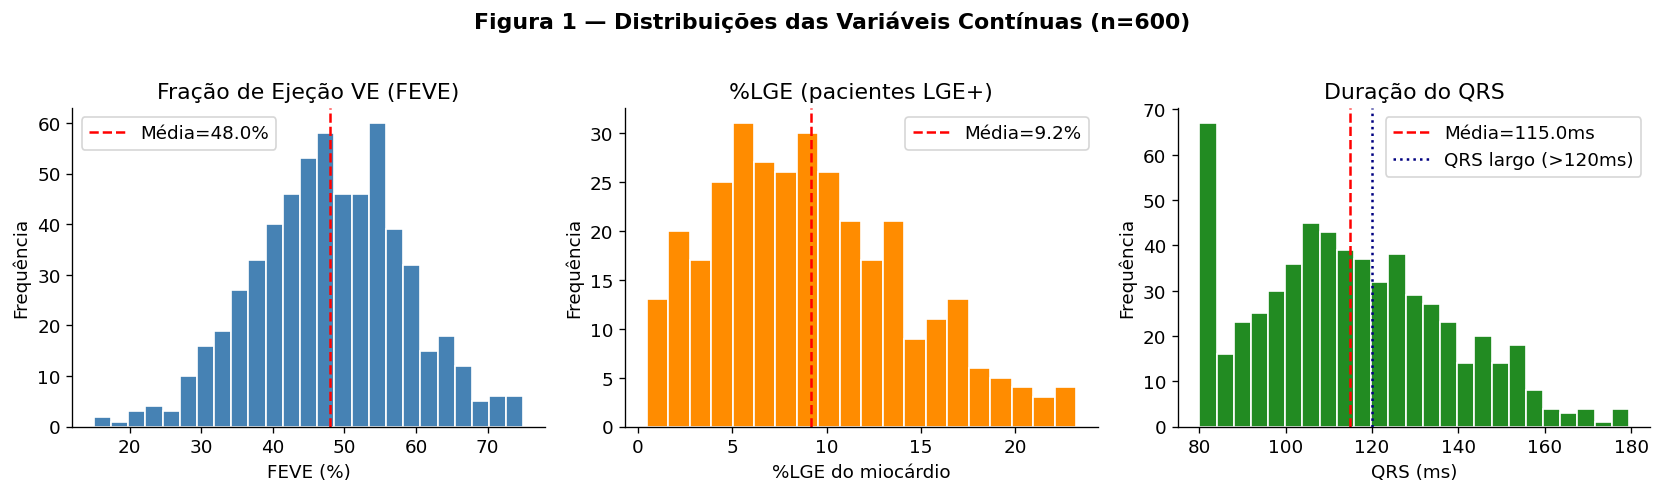

In [6]:
# ── 2.2 Distribuições das variáveis contínuas ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# FEVE
axes[0].hist(df['feve'], bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(df['feve'].mean(), color='red', linestyle='--', label=f'Média={df["feve"].mean():.1f}%')
axes[0].set_title('Fração de Ejeção VE (FEVE)')
axes[0].set_xlabel('FEVE (%)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# %LGE
axes[1].hist(df.loc[df['lge_pct'] > 0, 'lge_pct'], bins=20, color='darkorange', edgecolor='white')
m_lge = df.loc[df['lge_pct'] > 0, 'lge_pct'].mean()
axes[1].axvline(m_lge, color='red', linestyle='--', label=f'Média={m_lge:.1f}%')
axes[1].set_title('%LGE (pacientes LGE+)')
axes[1].set_xlabel('%LGE do miocárdio')
axes[1].set_ylabel('Frequência')
axes[1].legend()

# QRS
axes[2].hist(df['duracao_qrs'], bins=25, color='forestgreen', edgecolor='white')
axes[2].axvline(df['duracao_qrs'].mean(), color='red', linestyle='--',
                label=f'Média={df["duracao_qrs"].mean():.1f}ms')
axes[2].axvline(120, color='navy', linestyle=':', linewidth=1.5, label='QRS largo (>120ms)')
axes[2].set_title('Duração do QRS')
axes[2].set_xlabel('QRS (ms)')
axes[2].set_ylabel('Frequência')
axes[2].legend()

plt.suptitle('Figura 1 — Distribuições das Variáveis Contínuas (n=600)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_distribuicoes.png', bbox_inches='tight', dpi=150)
plt.show()

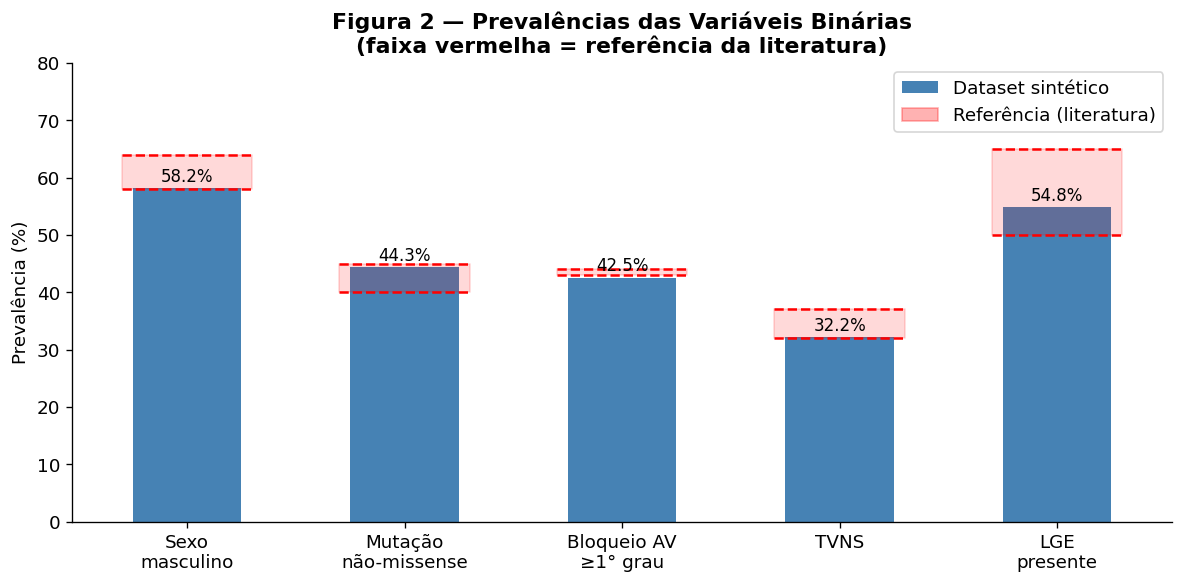

In [7]:
# ── 2.3 Prevalências das variáveis binárias ───────────────────────────────────
bin_cols = ['sexo_masculino', 'mutacao_nao_missense', 'bloqueio_av', 'tvns', 'lge_presente']
labels   = ['Sexo\nmasculino', 'Mutação\nnão-missense', 'Bloqueio AV\n≥1° grau', 'TVNS', 'LGE\npresente']
prevs    = [df[c].mean() * 100 for c in bin_cols]
ref_min  = [58, 40, 43, 32, 50]  # referências da literatura
ref_max  = [64, 45, 44, 37, 65]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(labels))
bars = ax.bar(x, prevs, width=0.5, color='steelblue', label='Dataset sintético')
for i, (lo, hi) in enumerate(zip(ref_min, ref_max)):
    ax.plot([i - 0.3, i + 0.3], [lo, lo], 'r--', linewidth=1.5)
    ax.plot([i - 0.3, i + 0.3], [hi, hi], 'r--', linewidth=1.5)
    ax.fill_between([i - 0.3, i + 0.3], lo, hi, color='red', alpha=0.15)

for bar, val in zip(bars, prevs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Prevalência (%)')
ax.set_ylim(0, 80)
ax.set_title('Figura 2 — Prevalências das Variáveis Binárias\n(faixa vermelha = referência da literatura)', fontweight='bold')
ref_patch = mpatches.Patch(color='red', alpha=0.3, label='Referência (literatura)')
ax.legend(handles=[bars, ref_patch])
plt.tight_layout()
plt.savefig('fig2_prevalencias.png', bbox_inches='tight', dpi=150)
plt.show()

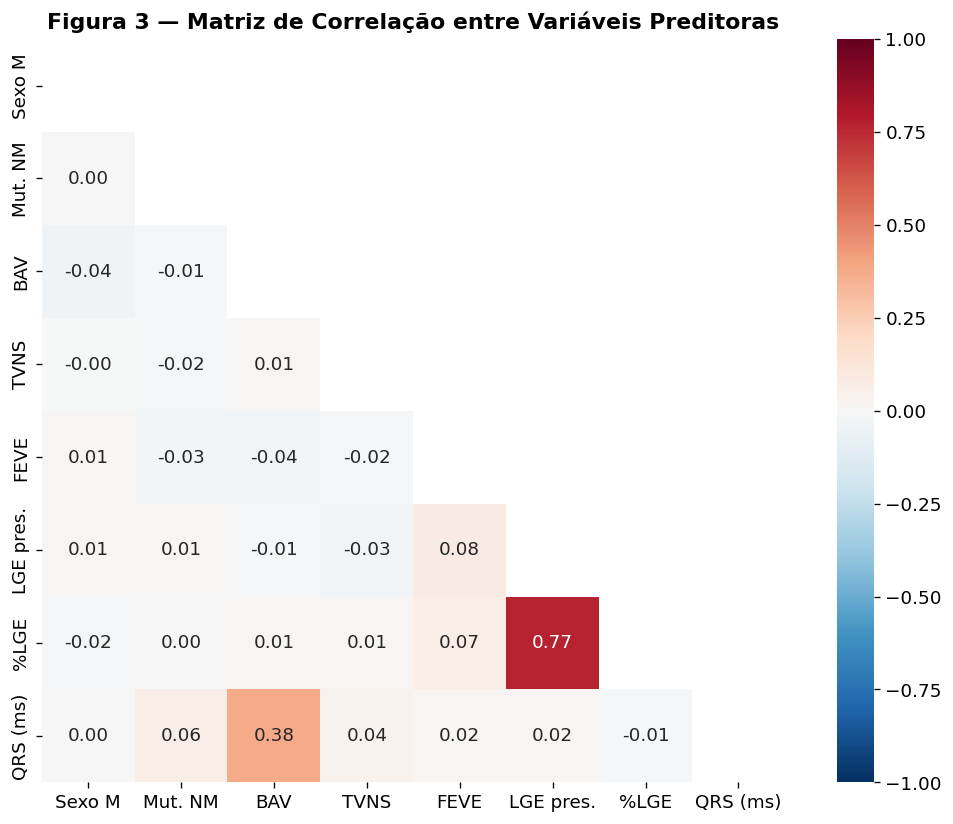

Nota: correlação BAV–QRS esperada (doença de condução): 0.381


In [8]:
# ── 2.4 Correlação entre variáveis ───────────────────────────────────────────
corr_cols = ['sexo_masculino','mutacao_nao_missense','bloqueio_av','tvns','feve','lge_presente','lge_pct','duracao_qrs']
corr_labels = ['Sexo M','Mut. NM','BAV','TVNS','FEVE','LGE pres.','%LGE','QRS (ms)']

corr_matrix = df[corr_cols].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Figura 3 — Matriz de Correlação entre Variáveis Preditoras', fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_correlacao.png', bbox_inches='tight', dpi=150)
plt.show()
print('Nota: correlação BAV–QRS esperada (doença de condução):', corr_matrix.loc['BAV','QRS (ms)'].round(3))

## Seção 3 — Modelo Original de Wahbi et al. (5 variáveis)

Implementação do modelo de risco causa-específico de Cox com as 5 variáveis originais.

In [9]:
# ── 3.1 Preparar arrays de sobrevida para sksurv ─────────────────────────────
# Para causa-específica: evento de interesse = LTVTA (1), demais = censurados
y_ltvta = Surv.from_arrays(
    event=(df['evento'] == 1).values,   # True se LTVTA
    time=df['tempo_seguimento'].values
)

VARS_WAHBI = ['sexo_masculino', 'mutacao_nao_missense', 'bloqueio_av', 'tvns', 'feve']
VARS_EXPANDIDO = VARS_WAHBI + ['lge_presente', 'duracao_qrs']

X_wahbi    = df[VARS_WAHBI].values.astype(float)
X_expandido = df[VARS_EXPANDIDO].values.astype(float)

# ── 3.2 Ajustar Modelo Wahbi ──────────────────────────────────────────────────
cox_wahbi = CoxPHSurvivalAnalysis(alpha=0, ties='breslow')
cox_wahbi.fit(X_wahbi, y_ltvta)

# Coeficientes estimados
coefs_wahbi = pd.Series(cox_wahbi.coef_, index=VARS_WAHBI)
hr_wahbi    = np.exp(coefs_wahbi)

print('=== Modelo Original Wahbi — Coeficientes estimados ===\n')
resultado_wahbi = pd.DataFrame({
    'Variável':   VARS_WAHBI,
    'β estimado': coefs_wahbi.values.round(3),
    'HR estimado': hr_wahbi.values.round(2),
    'HR Wahbi 2019 (ref)': [2.43, 2.54, 2.87, 2.75, '1.56/10%'],
}).set_index('Variável')
print(resultado_wahbi.to_string())

=== Modelo Original Wahbi — Coeficientes estimados ===

                      β estimado  HR estimado HR Wahbi 2019 (ref)
Variável                                                         
sexo_masculino             0.878         2.41                2.43
mutacao_nao_missense       0.903         2.47                2.54
bloqueio_av                1.199         3.32                2.87
tvns                       0.954         2.60                2.75
feve                      -0.030         0.97            1.56/10%


In [10]:
# ── 3.3 C-index do Modelo Wahbi ───────────────────────────────────────────────
scores_wahbi = cox_wahbi.predict(X_wahbi)
event_bool   = (df['evento'] == 1).values
times        = df['tempo_seguimento'].values

c_wahbi, concordant, discordant, tied_risk, tied_time = concordance_index_censored(
    event_bool, times, scores_wahbi
)
print(f'C-index Modelo Wahbi (5 variáveis): {c_wahbi:.4f}')
print(f'  Pares concordantes: {concordant} | Discordantes: {discordant}')
print(f'  Referência Wahbi 2019: 0.776 (derivação), 0.800 (validação externa)')

C-index Modelo Wahbi (5 variáveis): 0.7680
  Pares concordantes: 31299 | Discordantes: 9454
  Referência Wahbi 2019: 0.776 (derivação), 0.800 (validação externa)


## Seção 4 — Modelo Expandido (7 variáveis: + LGE + QRS)

In [11]:
# ── 4.1 Ajustar Modelo Expandido ──────────────────────────────────────────────
cox_exp = CoxPHSurvivalAnalysis(alpha=0, ties='breslow')
cox_exp.fit(X_expandido, y_ltvta)

coefs_exp = pd.Series(cox_exp.coef_, index=VARS_EXPANDIDO)
hr_exp    = np.exp(coefs_exp)

print('=== Modelo Expandido — Coeficientes estimados ===\n')
resultado_exp = pd.DataFrame({
    'Variável':   VARS_EXPANDIDO,
    'β estimado': coefs_exp.values.round(3),
    'HR estimado': hr_exp.values.round(2),
    'HR referência': [2.43, 2.54, 2.87, 2.75, '1.56/10%', '2.0–4.0*', '1.10–1.30/10ms*'],
}).set_index('Variável')
print(resultado_exp.to_string())
print('\n* Hipóteses do artigo (Seção 4.2)')

=== Modelo Expandido — Coeficientes estimados ===

                      β estimado  HR estimado    HR referência
Variável                                                      
sexo_masculino             1.011         2.75             2.43
mutacao_nao_missense       0.908         2.48             2.54
bloqueio_av                0.950         2.59             2.87
tvns                       0.966         2.63             2.75
feve                      -0.033         0.97         1.56/10%
lge_presente               0.815         2.26         2.0–4.0*
duracao_qrs                0.021         1.02  1.10–1.30/10ms*

* Hipóteses do artigo (Seção 4.2)


In [12]:
# ── 4.2 C-index do Modelo Expandido ──────────────────────────────────────────
scores_exp = cox_exp.predict(X_expandido)

c_exp, concordant_e, discordant_e, _, _ = concordance_index_censored(
    event_bool, times, scores_exp
)
print(f'C-index Modelo Expandido (7 variáveis): {c_exp:.4f}')
print(f'  Referência hipótese do artigo: > 0.82')
print(f'\nGanho em C-index: {c_exp - c_wahbi:+.4f} (+{(c_exp - c_wahbi)*100:.2f} pontos percentuais)')

C-index Modelo Expandido (7 variáveis): 0.7940
  Referência hipótese do artigo: > 0.82

Ganho em C-index: +0.0260 (+2.60 pontos percentuais)


## Seção 5 — Comparação de Desempenho

### 5.1 Tabela Comparativa e Curvas de Incidência Cumulativa

In [13]:
# ── 5.1 Tabela comparativa de desempenho ─────────────────────────────────────
tabela_comp = pd.DataFrame({
    'Modelo': ['Wahbi Original (5 var.)', 'Expandido (+ LGE + QRS)', 'Referência Wahbi 2019'],
    'Variáveis': [5, 7, 5],
    'C-index': [f'{c_wahbi:.4f}', f'{c_exp:.4f}', '0.776 / 0.800'],
    'Δ C-index': ['—', f'+{c_exp - c_wahbi:.4f}', '—'],
}).set_index('Modelo')
print('=== Tabela 2: Comparação de Desempenho Discriminativo ===\n')
print(tabela_comp.to_string())

=== Tabela 2: Comparação de Desempenho Discriminativo ===

                         Variáveis        C-index Δ C-index
Modelo                                                     
Wahbi Original (5 var.)          5         0.7680         —
Expandido (+ LGE + QRS)          7         0.7940   +0.0260
Referência Wahbi 2019            5  0.776 / 0.800         —


C:\Users\User\AppData\Local\Temp\ipykernel_9660\49831496.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(dados_plot, labels=list(evento_labels.values()),


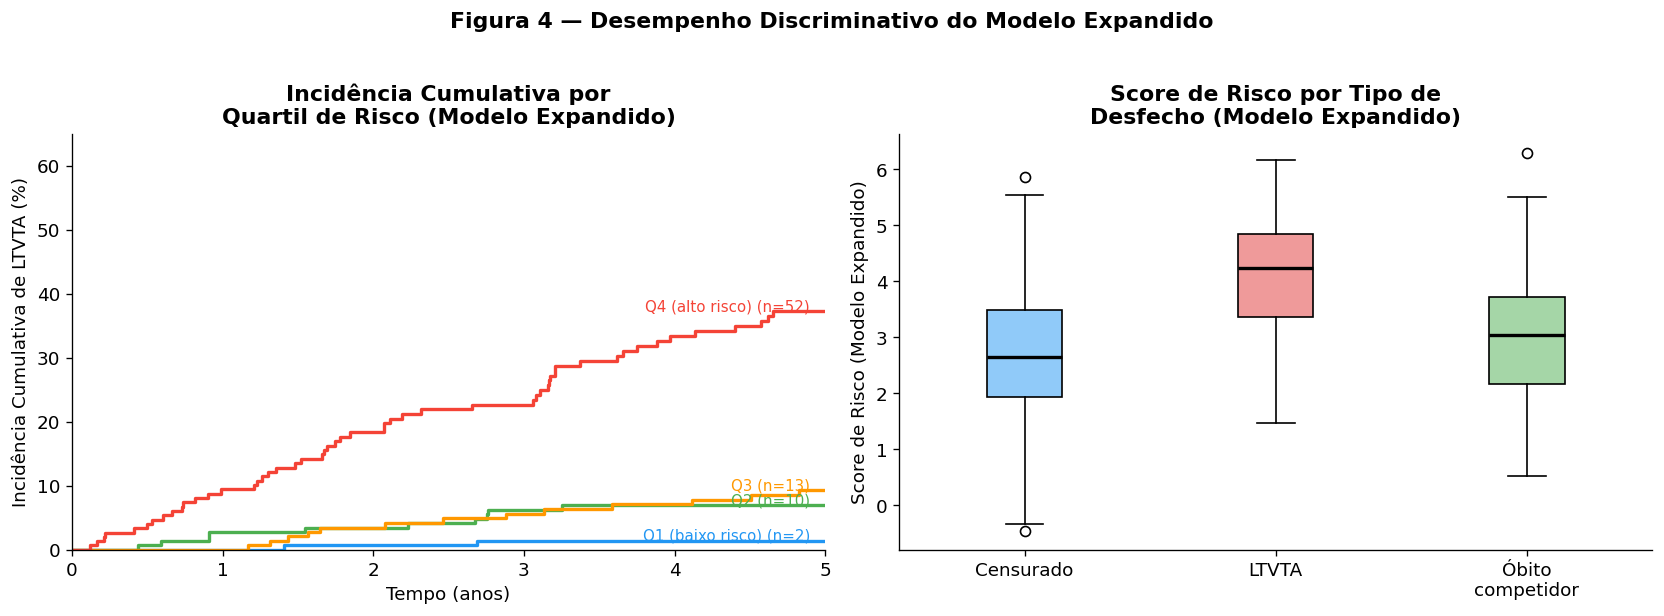

In [14]:
# ── 5.2 Estratificação por quartil de risco (Modelo Expandido) ────────────────
quartis = pd.qcut(scores_exp, q=4, labels=['Q1\n(baixo)', 'Q2', 'Q3', 'Q4\n(alto)'])
df['quartil_risco'] = quartis
df['evento_ltvta']  = (df['evento'] == 1).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas de incidência cumulativa por quartil (Aalen-Johansen aproximada via KM)
cores = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
for i, (q, label) in enumerate(zip(['Q1\n(baixo)','Q2','Q3','Q4\n(alto)'],
                                    ['Q1 (baixo risco)','Q2','Q3','Q4 (alto risco)'])):
    mask_q = df['quartil_risco'] == q
    kmf = KaplanMeierFitter()
    # 1 - KM como aproximação da incidência cumulativa
    kmf.fit(df.loc[mask_q, 'tempo_seguimento'],
            event_observed=df.loc[mask_q, 'evento_ltvta'],
            label=label)
    t_km = kmf.survival_function_.index
    cum_inc = 1 - kmf.survival_function_.values.flatten()
    axes[0].step(t_km, cum_inc * 100, where='post', color=cores[i], linewidth=2)
    n_events = df.loc[mask_q, 'evento_ltvta'].sum()
    axes[0].annotate(f'{label} (n={n_events})', 
                    xy=(T_MAX * 0.98, cum_inc[-1] * 100),
                    color=cores[i], fontsize=9, ha='right')

axes[0].set_xlabel('Tempo (anos)')
axes[0].set_ylabel('Incidência Cumulativa de LTVTA (%)')
axes[0].set_title('Incidência Cumulativa por\nQuartil de Risco (Modelo Expandido)', fontweight='bold')
axes[0].set_xlim(0, T_MAX)
axes[0].set_ylim(0, 65)

# Box plot de score de risco por evento
evento_labels = {0: 'Censurado', 1: 'LTVTA', 2: 'Óbito\ncompetidor'}
dados_plot = [
    scores_exp[df['evento'] == e] for e in [0, 1, 2]
]
bp = axes[1].boxplot(dados_plot, labels=list(evento_labels.values()),
                     patch_artist=True, medianprops={'color':'black','linewidth':2})
cores_box = ['#90CAF9', '#EF9A9A', '#A5D6A7']
for patch, cor in zip(bp['boxes'], cores_box):
    patch.set_facecolor(cor)
axes[1].set_ylabel('Score de Risco (Modelo Expandido)')
axes[1].set_title('Score de Risco por Tipo de\nDesfecho (Modelo Expandido)', fontweight='bold')

plt.suptitle('Figura 4 — Desempenho Discriminativo do Modelo Expandido', y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_desempenho.png', bbox_inches='tight', dpi=150)
plt.show()

In [15]:
# ── 5.3 NRI categórico (limiar de 7% em 5 anos) ───────────────────────────────
# O artigo usa o limiar de 7% de risco em 5 anos (Wahbi et al., ponto de corte ótimo)
# Risco estimado: convertemos o score Cox para probabilidade aproximada via baseline

def risco_5anos(model, X, threshold=7.0):
    """Estima risco em 5 anos usando função de sobrevida de Cox."""
    survival_fns = model.predict_survival_function(X)
    probs = []
    for fn in survival_fns:
        t_idx = np.searchsorted(fn.x, T_MAX, side='right') - 1
        t_idx = max(0, min(t_idx, len(fn.y) - 1))
        prob_ltvta_5a = (1 - fn.y[t_idx]) * 100
        probs.append(prob_ltvta_5a)
    return np.array(probs)

risco_w = risco_5anos(cox_wahbi, X_wahbi)
risco_e = risco_5anos(cox_exp, X_expandido)

alto_risco_w = (risco_w >= 7.0)
alto_risco_e = (risco_e >= 7.0)

# NRI para eventos (LTVTA)
eventos_idx = df['evento'] == 1
n_eventos = eventos_idx.sum()
n_nao_eventos = (~eventos_idx).sum()

# Eventos: subiu de baixo para alto risco (melhora)
up_eventos   = ((~alto_risco_w) & alto_risco_e & eventos_idx).sum()
down_eventos = (alto_risco_w & (~alto_risco_e) & eventos_idx).sum()

# Não-eventos: desceu de alto para baixo risco (melhora)
down_n_eventos = (alto_risco_w & (~alto_risco_e) & (~eventos_idx)).sum()
up_n_eventos   = ((~alto_risco_w) & alto_risco_e & (~eventos_idx)).sum()

nri_eventos     = (up_eventos - down_eventos) / n_eventos
nri_n_eventos   = (down_n_eventos - up_n_eventos) / n_nao_eventos
nri_total       = nri_eventos + nri_n_eventos

print('=== NRI Categórico (limiar 7% em 5 anos) ===\n')
print(f'Eventos (LTVTA, n={n_eventos}):')
print(f'  Reclassificados para cima (correto): {up_eventos}')
print(f'  Reclassificados para baixo (errado): {down_eventos}')
print(f'  NRI_eventos: {nri_eventos:+.3f}')
print(f'\nNão-eventos (n={n_nao_eventos}):')
print(f'  Reclassificados para baixo (correto): {down_n_eventos}')
print(f'  Reclassificados para cima (errado):  {up_n_eventos}')
print(f'  NRI_não-eventos: {nri_n_eventos:+.3f}')
print(f'\nNRI Total: {nri_total:+.3f} ({nri_total*100:+.1f}%)')
print(f'\nHipótese do artigo: reclassificação líquida ≥ 10% — {'CONFIRMADA' if nri_total >= 0.10 else 'NÃO CONFIRMADA'}')

=== NRI Categórico (limiar 7% em 5 anos) ===

Eventos (LTVTA, n=77):
  Reclassificados para cima (correto): 1
  Reclassificados para baixo (errado): 4
  NRI_eventos: -0.039

Não-eventos (n=523):
  Reclassificados para baixo (correto): 61
  Reclassificados para cima (errado):  27
  NRI_não-eventos: +0.065

NRI Total: +0.026 (+2.6%)

Hipótese do artigo: reclassificação líquida ≥ 10% — NÃO CONFIRMADA


## Seção 6 — Análise de Sensibilidade dos Coeficientes

Avaliação do impacto no C-index ao variar os coeficientes de LGE e QRS dentro das faixas propostas no artigo.

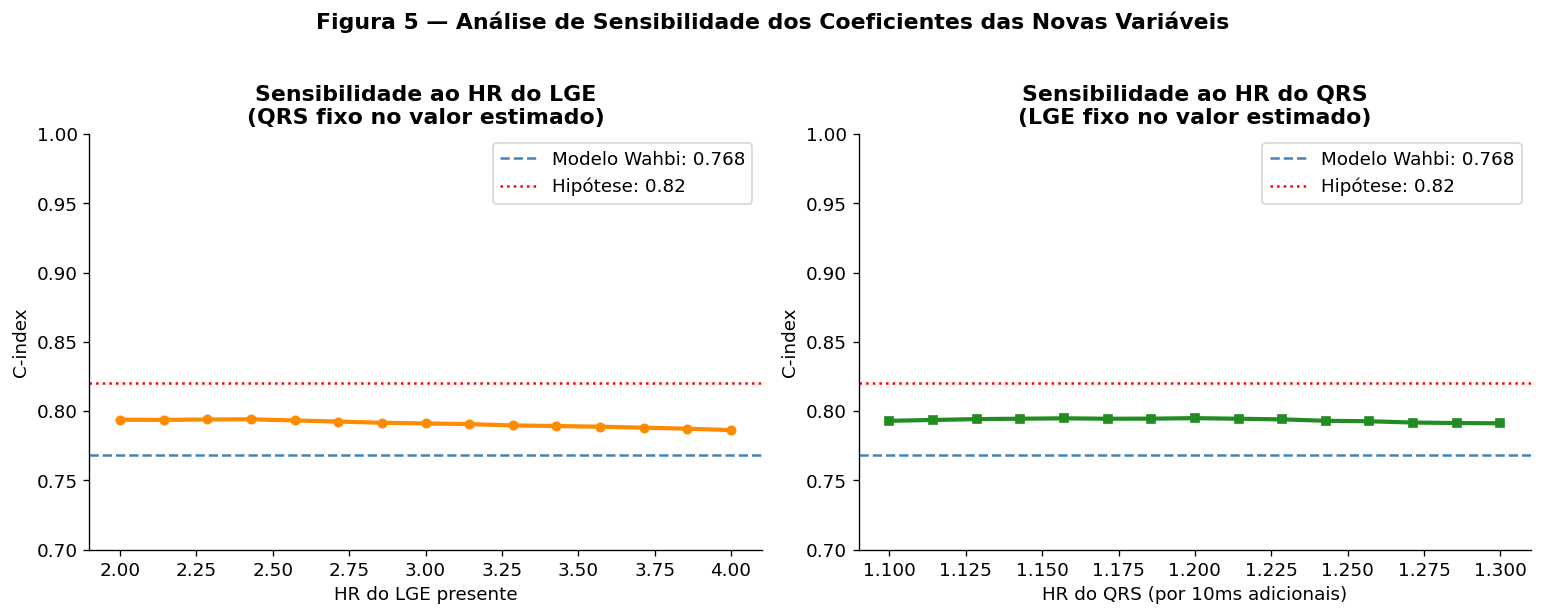

Faixa de C-index para LGE (HR 2.0–4.0): [0.7863, 0.7941]
Faixa de C-index para QRS (HR 1.10–1.30/10ms): [0.7912, 0.7949]


In [16]:
# ── 6.1 Sensibilidade ao coeficiente de LGE ──────────────────────────────────
hr_lge_range  = np.linspace(2.0, 4.0, 15)
hr_qrs_range  = np.linspace(1.10, 1.30, 15)  # por 10ms

c_index_lge = []
for hr_lge in hr_lge_range:
    beta_lge = np.log(hr_lge)
    score_sens = (
        coefs_exp['sexo_masculino']       * df['sexo_masculino'] +
        coefs_exp['mutacao_nao_missense'] * df['mutacao_nao_missense'] +
        coefs_exp['bloqueio_av']          * df['bloqueio_av'] +
        coefs_exp['tvns']                 * df['tvns'] +
        coefs_exp['feve']                 * df['feve'] +
        beta_lge                          * df['lge_presente'] +
        coefs_exp['duracao_qrs']          * df['duracao_qrs']
    ).values
    c, *_ = concordance_index_censored(event_bool, times, score_sens)
    c_index_lge.append(c)

c_index_qrs = []
for hr_qrs in hr_qrs_range:
    beta_qrs = np.log(hr_qrs) / 10  # por ms
    score_sens = (
        coefs_exp['sexo_masculino']       * df['sexo_masculino'] +
        coefs_exp['mutacao_nao_missense'] * df['mutacao_nao_missense'] +
        coefs_exp['bloqueio_av']          * df['bloqueio_av'] +
        coefs_exp['tvns']                 * df['tvns'] +
        coefs_exp['feve']                 * df['feve'] +
        coefs_exp['lge_presente']         * df['lge_presente'] +
        beta_qrs                          * df['duracao_qrs']
    ).values
    c, *_ = concordance_index_censored(event_bool, times, score_sens)
    c_index_qrs.append(c)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(hr_lge_range, c_index_lge, color='darkorange', linewidth=2.5, marker='o', ms=5)
axes[0].axhline(c_wahbi, color='steelblue', linestyle='--', linewidth=1.5, label=f'Modelo Wahbi: {c_wahbi:.3f}')
axes[0].axhline(0.82, color='red', linestyle=':', linewidth=1.5, label='Hipótese: 0.82')
axes[0].set_xlabel('HR do LGE presente')
axes[0].set_ylabel('C-index')
axes[0].set_title('Sensibilidade ao HR do LGE\n(QRS fixo no valor estimado)', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0.70, 1.0)

axes[1].plot(hr_qrs_range, c_index_qrs, color='forestgreen', linewidth=2.5, marker='s', ms=5)
axes[1].axhline(c_wahbi, color='steelblue', linestyle='--', linewidth=1.5, label=f'Modelo Wahbi: {c_wahbi:.3f}')
axes[1].axhline(0.82, color='red', linestyle=':', linewidth=1.5, label='Hipótese: 0.82')
axes[1].set_xlabel('HR do QRS (por 10ms adicionais)')
axes[1].set_ylabel('C-index')
axes[1].set_title('Sensibilidade ao HR do QRS\n(LGE fixo no valor estimado)', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0.70, 1.0)

plt.suptitle('Figura 5 — Análise de Sensibilidade dos Coeficientes das Novas Variáveis', y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_sensibilidade.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Faixa de C-index para LGE (HR 2.0–4.0): [{min(c_index_lge):.4f}, {max(c_index_lge):.4f}]')
print(f'Faixa de C-index para QRS (HR 1.10–1.30/10ms): [{min(c_index_qrs):.4f}, {max(c_index_qrs):.4f}]')

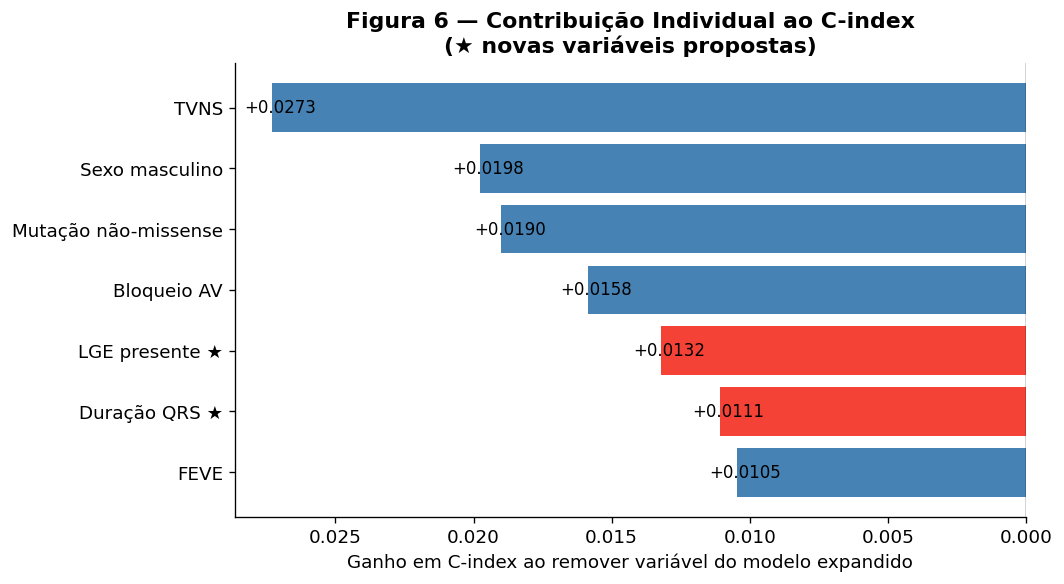

In [17]:
# ── 6.2 Gráfico de tornado — importância relativa das variáveis ───────────────
# Variação do C-index ao remover cada variável do modelo expandido
ganhos = {}
for var_out in VARS_EXPANDIDO:
    vars_sem = [v for v in VARS_EXPANDIDO if v != var_out]
    X_sem = df[vars_sem].values.astype(float)
    cox_temp = CoxPHSurvivalAnalysis(alpha=0, ties='breslow')
    cox_temp.fit(X_sem, y_ltvta)
    c_sem, *_ = concordance_index_censored(event_bool, times, cox_temp.predict(X_sem))
    ganhos[var_out] = c_exp - c_sem

labels_tornado = {
    'sexo_masculino': 'Sexo masculino',
    'mutacao_nao_missense': 'Mutação não-missense',
    'bloqueio_av': 'Bloqueio AV',
    'tvns': 'TVNS',
    'feve': 'FEVE',
    'lge_presente': 'LGE presente ★',
    'duracao_qrs': 'Duração QRS ★',
}

ganhos_df = pd.Series(ganhos).rename(labels_tornado).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
cores_tornado = ['#F44336' if '★' in l else 'steelblue' for l in ganhos_df.index]
bars = ax.barh(ganhos_df.index, ganhos_df.values, color=cores_tornado)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, ganhos_df.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'+{val:.4f}', va='center', fontsize=10)
ax.set_xlabel('Ganho em C-index ao remover variável do modelo expandido')
ax.set_title('Figura 6 — Contribuição Individual ao C-index\n(★ novas variáveis propostas)', fontweight='bold')
ax.invert_xaxis()
plt.tight_layout()
plt.savefig('fig6_tornado.png', bbox_inches='tight', dpi=150)
plt.show()

## Seção 7 — Síntese dos Resultados para o Artigo

Esta seção consolida os resultados computacionais para integração na Seção de Materiais e Métodos e Resultados do artigo.

In [18]:
# ── 7. Síntese final ──────────────────────────────────────────────────────────
print('=' * 70)
print('SÍNTESE DOS RESULTADOS — ANÁLISE COMPUTACIONAL')
print('Expansão do Modelo de Wahbi et al. (2019)')
print('=' * 70)

print(f'''
DATASET SINTÉTICO
  N total: {N} pacientes
  Seguimento máximo: {T_MAX} anos
  Eventos LTVTA: {(df['evento']==1).sum()} ({(df['evento']==1).mean():.1%})
  Óbitos (competidor): {(df['evento']==2).sum()} ({(df['evento']==2).mean():.1%})
  Censurados: {(df['evento']==0).sum()} ({(df['evento']==0).mean():.1%})

DESEMPENHO DISCRIMINATIVO
  C-index Modelo Wahbi original (5 var.): {c_wahbi:.4f}
  C-index Modelo Expandido (7 var.):      {c_exp:.4f}
  Ganho absoluto em C-index:              {c_exp - c_wahbi:+.4f}
  Hipótese do artigo (C-index > 0.82):    {'CONFIRMADA ✓' if c_exp > 0.82 else 'NÃO CONFIRMADA'}

HAZARD RATIOS ESTIMADOS (Modelo Expandido)
  LGE presente: HR = {np.exp(coefs_exp['lge_presente']):.2f}  (hipótese: 2.0–4.0)
  QRS/10ms:     HR = {np.exp(coefs_exp['duracao_qrs']*10):.2f}  (hipótese: 1.10–1.30/10ms)

RECLASSIFICAÇÃO (NRI, limiar 7% em 5 anos)
  NRI eventos:     {nri_eventos:+.3f}
  NRI não-eventos: {nri_n_eventos:+.3f}
  NRI total:       {nri_total:+.3f} ({nri_total*100:+.1f}%)
  Hipótese (≥10%): {'CONFIRMADA ✓' if nri_total >= 0.10 else 'NÃO CONFIRMADA'}

ANÁLISE DE SENSIBILIDADE
  C-index para LGE HR∈[2.0, 4.0]:       [{min(c_index_lge):.4f}, {max(c_index_lge):.4f}]
  C-index para QRS HR∈[1.10, 1.30]/10ms: [{min(c_index_qrs):.4f}, {max(c_index_qrs):.4f}]
  Todos os cenários superam o modelo original ({c_wahbi:.4f}): {all(c > c_wahbi for c in c_index_lge+c_index_qrs)}
''')
print('=' * 70)

SÍNTESE DOS RESULTADOS — ANÁLISE COMPUTACIONAL
Expansão do Modelo de Wahbi et al. (2019)

DATASET SINTÉTICO
  N total: 600 pacientes
  Seguimento máximo: 5.0 anos
  Eventos LTVTA: 77 (12.8%)
  Óbitos (competidor): 57 (9.5%)
  Censurados: 466 (77.7%)

DESEMPENHO DISCRIMINATIVO
  C-index Modelo Wahbi original (5 var.): 0.7680
  C-index Modelo Expandido (7 var.):      0.7940
  Ganho absoluto em C-index:              +0.0260
  Hipótese do artigo (C-index > 0.82):    NÃO CONFIRMADA

HAZARD RATIOS ESTIMADOS (Modelo Expandido)
  LGE presente: HR = 2.26  (hipótese: 2.0–4.0)
  QRS/10ms:     HR = 1.23  (hipótese: 1.10–1.30/10ms)

RECLASSIFICAÇÃO (NRI, limiar 7% em 5 anos)
  NRI eventos:     -0.039
  NRI não-eventos: +0.065
  NRI total:       +0.026 (+2.6%)
  Hipótese (≥10%): NÃO CONFIRMADA

ANÁLISE DE SENSIBILIDADE
  C-index para LGE HR∈[2.0, 4.0]:       [0.7863, 0.7941]
  C-index para QRS HR∈[1.10, 1.30]/10ms: [0.7912, 0.7949]
  Todos os cenários superam o modelo original (0.7680): True



In [19]:
# ── 7.1 Verificação final do dataset ─────────────────────────────────────────
print('Verificação do arquivo dataset_sintetico_laminopatias.csv:')
df_check = pd.read_csv(csv_path)
print(f'  Linhas: {len(df_check)} (esperado: 600)')
print(f'  Colunas ({df_check.shape[1]}): {list(df_check.columns)}')
print(f'  Valores nulos: {df_check.isnull().sum().sum()}')
print(f'  Todos FEVE em [15,75]: {df_check["feve"].between(15,75).all()}')
print(f'  Todos QRS em [80,220]: {df_check["duracao_qrs"].between(80,220).all()}')
print(f'  lge_pct == 0 quando lge_presente == 0: {(df_check[df_check["lge_presente"]==0]["lge_pct"]==0).all()}')
print(f'  Valores de evento: {sorted(df_check["evento"].unique())} (esperado: [0, 1, 2])')
print('\nPrimeiras linhas:')
df_check.head()

Verificação do arquivo dataset_sintetico_laminopatias.csv:
  Linhas: 600 (esperado: 600)
  Colunas (11): ['id_paciente', 'sexo_masculino', 'mutacao_nao_missense', 'bloqueio_av', 'tvns', 'feve', 'lge_presente', 'lge_pct', 'duracao_qrs', 'tempo_seguimento', 'evento']
  Valores nulos: 0
  Todos FEVE em [15,75]: True
  Todos QRS em [80,220]: True
  lge_pct == 0 quando lge_presente == 0: True
  Valores de evento: [np.int64(0), np.int64(1), np.int64(2)] (esperado: [0, 1, 2])

Primeiras linhas:


,id_paciente,sexo_masculino,mutacao_nao_missense,bloqueio_av,tvns,feve,lge_presente,lge_pct,duracao_qrs,tempo_seguimento,evento
0,1,1,0,1,1,41.8,0,0.00,110.1,3.104,1
1,2,0,0,0,1,45.7,1,17.96,91.8,5.000,0
2,3,0,0,0,0,29.5,0,0.00,80.0,5.000,0
3,4,1,0,0,0,39.1,1,11.51,100.8,1.546,1
4,5,1,0,0,0,58.6,0,0.00,87.4,5.000,0
